In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("../data/cleaned/cleaned_hr_emp_data.csv")

In [3]:
df.shape

(1470, 31)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

In [5]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [6]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [7]:
df['Attrition'].value_counts(normalize=True)*100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

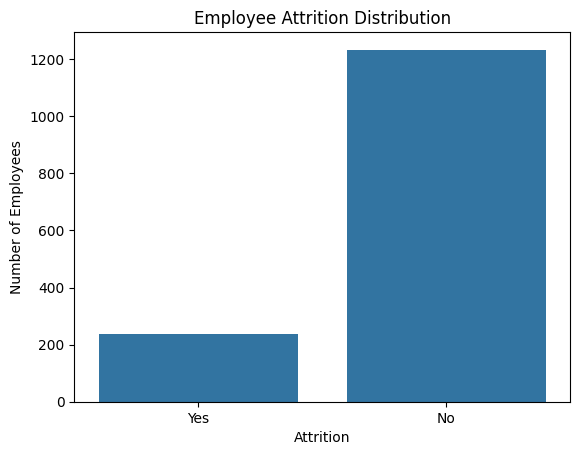

In [8]:
sns.countplot(data=df,x='Attrition')
plt.title('Employee Attrition Distribution')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')
plt.show()

In [9]:
age=[18,25,35,45,55,65]
label=['18-25','26-35','35-45','46-55','56-65']
df['AgeGroup']=pd.cut(df['Age'],bins=age,labels=label)


In [10]:
df['AgeGroup']

0       35-45
1       46-55
2       35-45
3       26-35
4       26-35
        ...  
1465    35-45
1466    35-45
1467    26-35
1468    46-55
1469    26-35
Name: AgeGroup, Length: 1470, dtype: category
Categories (5, object): ['18-25' < '26-35' < '35-45' < '46-55' < '56-65']

In [11]:
age_attrition=df.groupby('AgeGroup',observed=True)['Attrition'].apply(lambda x:(x=='Yes').mean()*100)

In [12]:
age_attrition.sort_values(ascending=False,inplace=True)

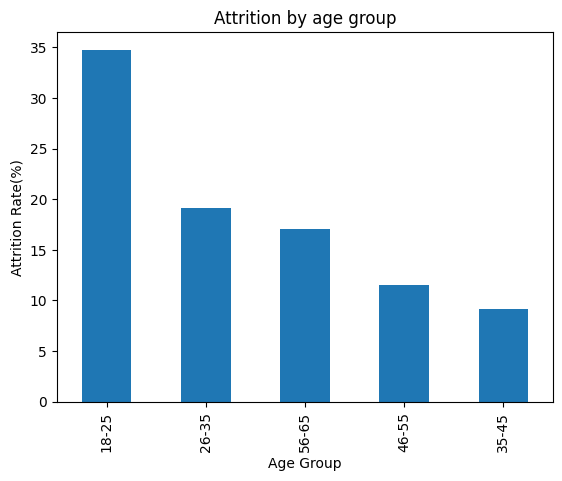

In [13]:
age_attrition.plot(kind='bar')
plt.title("Attrition by age group")
plt.xlabel('Age Group')
plt.ylabel('Attrition Rate(%)')
plt.show()

In [14]:
gender_attrition=df.groupby('Gender')['Attrition'].apply(lambda x:(x=='Yes').mean()*100)

In [15]:
gender_attrition

Gender
Female    14.795918
Male      17.006803
Name: Attrition, dtype: float64

In [16]:
marital_attrition=df.groupby('MaritalStatus')['Attrition'].apply(lambda x:(x=='Yes').mean()*100)
marital_attrition

MaritalStatus
Divorced    10.091743
Married     12.481426
Single      25.531915
Name: Attrition, dtype: float64

In [17]:
department_attrition=df.groupby('Department')['Attrition'].apply(lambda x:(x=='Yes').mean()*100)
department_attrition.sort_values(ascending=False,inplace=True)
department_attrition

Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750
Name: Attrition, dtype: float64

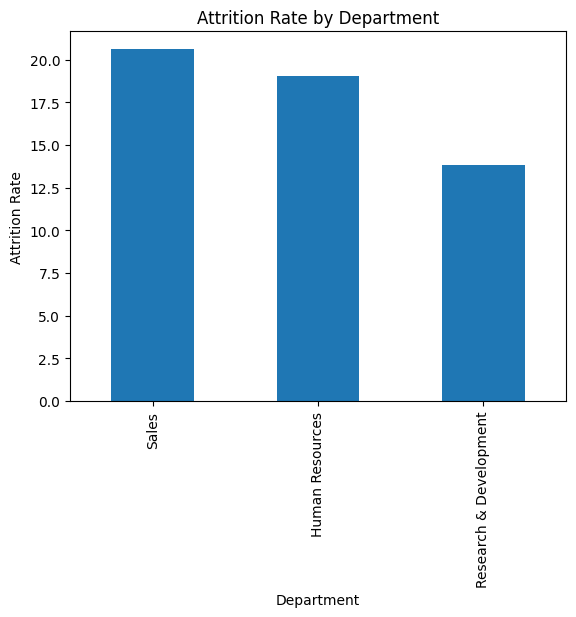

In [18]:
department_attrition.plot(kind='bar')
plt.title('Attrition Rate by Department')
plt.xlabel('Department')
plt.ylabel('Attrition Rate')
plt.show()

In [19]:
jobrole_attrition=df.groupby('JobRole')['Attrition'].apply(lambda x:(x=='Yes').mean()*100).sort_values(ascending=False)
jobrole_attrition

JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: Attrition, dtype: float64

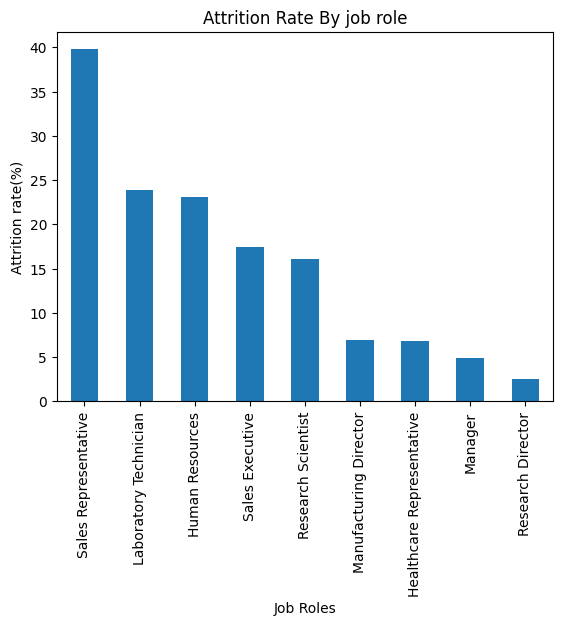

In [20]:
jobrole_attrition.plot(kind='bar')
plt.title('Attrition Rate By job role')
plt.xlabel('Job Roles')
plt.ylabel('Attrition rate(%)')
plt.show()

In [21]:
jobrole_attrition.head()

JobRole
Sales Representative     39.759036
Laboratory Technician    23.938224
Human Resources          23.076923
Sales Executive          17.484663
Research Scientist       16.095890
Name: Attrition, dtype: float64

In [22]:
df['JobLevel']

0       2
1       2
2       1
3       1
4       1
       ..
1465    2
1466    3
1467    2
1468    2
1469    2
Name: JobLevel, Length: 1470, dtype: int64

In [23]:
joblevel_attrition=df.groupby('JobLevel')['Attrition'].apply(lambda x:(x=='Yes').mean()*100).sort_values(ascending=False)
joblevel_attrition

JobLevel
1    26.335175
3    14.678899
2     9.737828
5     7.246377
4     4.716981
Name: Attrition, dtype: float64

In [24]:
overtime_attrition=df.groupby('OverTime')['Attrition'].apply(lambda x:(x=='Yes').mean()*100).sort_values(ascending=False)
overtime_attrition

OverTime
Yes    30.528846
No     10.436433
Name: Attrition, dtype: float64

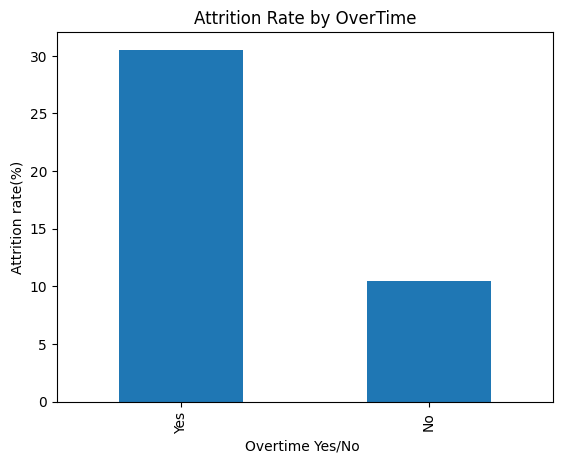

In [25]:
overtime_attrition.plot(kind='bar')
plt.title('Attrition Rate by OverTime')
plt.xlabel('Overtime Yes/No ')
plt.ylabel('Attrition rate(%)')
plt.show()

In [26]:
dept_overtime=df.groupby('Department')['OverTime'].apply(lambda x:(x=='Yes').mean()*100)
emp_dept_overtime=dept_overtime.idxmax()
emp_dept_overtime

'Sales'

In [27]:
travel_attrition=df.groupby('BusinessTravel')['Attrition'].apply(lambda x:(x=="Yes").mean()*100).sort_values(ascending=False)
travel_attrition

BusinessTravel
Travel_Frequently    24.909747
Travel_Rarely        14.956855
Non-Travel            8.000000
Name: Attrition, dtype: float64

#### Do Employees living farther from the workplace leave more ?

In [28]:
df.groupby('Attrition')['DistanceFromHome'].mean()

Attrition
No      8.915653
Yes    10.632911
Name: DistanceFromHome, dtype: float64

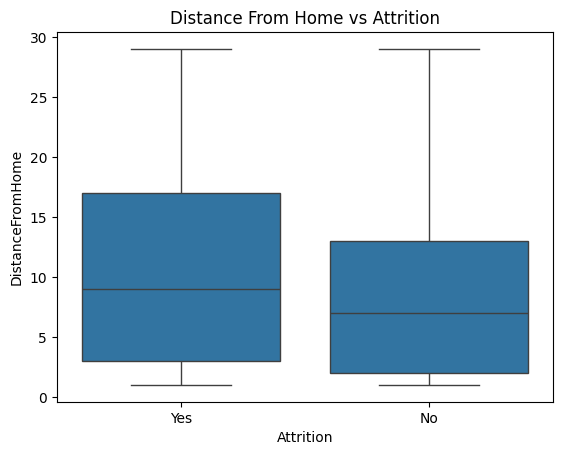

In [29]:
sns.boxplot(data=df,x='Attrition',y='DistanceFromHome')
plt.title('Distance From Home vs Attrition')
plt.show()

In [30]:
df.groupby('Attrition')['MonthlyIncome'].agg(['count','mean','median','min','max'])

,count,mean,median,min,max
Attrition,,,,,
No,1233,6832.739659,5204.0,1051,19999
Yes,237,4787.092827,3202.0,1009,19859


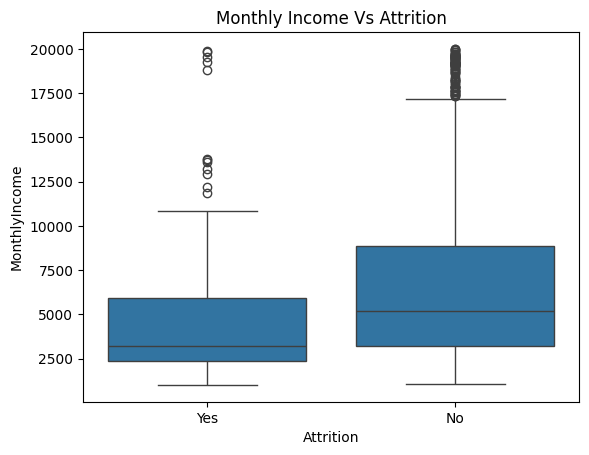

In [31]:
sns.boxplot(data=df,x='Attrition',y='MonthlyIncome')
plt.title('Monthly Income Vs Attrition')
plt.show()

In [32]:
pd.crosstab([df['Gender'],df['JobRole']],df['Attrition'],normalize='index')*100

Attrition                                No        Yes
Gender JobRole                                        
Female Healthcare Representative  90.196078   9.803922
       Human Resources            62.500000  37.500000
       Laboratory Technician      81.176471  18.823529
       Manager                    95.744681   4.255319
       Manufacturing Director     94.444444   5.555556
       Research Director          96.969697   3.030303
       Research Scientist         85.087719  14.912281
       Sales Executive            84.848485  15.151515
       Sales Representative       57.894737  42.105263
Male   Healthcare Representative  95.000000   5.000000
       Human Resources            83.333333  16.666667
       Laboratory Technician      73.563218  26.436782
       Manager                    94.545455   5.454545
       Manufacturing Director     91.780822   8.219178
       Research Director          97.872340   2.127660
       Research Scientist         83.146067  16.853933
       Sales Executive            80.927835  19.072165
       Sales Representative       62.222222  37.777778

In [33]:
pd.crosstab([df['MaritalStatus'],df['OverTime']],df['Attrition'],normalize='index')*100

Attrition                      No        Yes
MaritalStatus OverTime                      
Divorced      No        93.859649   6.140351
              Yes       80.808081  19.191919
Married       No        91.581109   8.418891
              Yes       76.881720  23.118280
Single        No        83.775811  16.224189
              Yes       50.381679  49.618321

In [34]:
pd.crosstab([df['Department'],df['JobRole']],df['Attrition'],normalize='index')*100

Attrition                                                 No        Yes
Department             JobRole                                         
Human Resources        Human Resources             76.923077  23.076923
                       Manager                    100.000000   0.000000
Research & Development Healthcare Representative   93.129771   6.870229
                       Laboratory Technician       76.061776  23.938224
                       Manager                     94.444444   5.555556
                       Manufacturing Director      93.103448   6.896552
                       Research Director           97.500000   2.500000
                       Research Scientist          83.904110  16.095890
Sales                  Manager                     94.594595   5.405405
                       Sales Executive             82.515337  17.484663
                       Sales Representative        60.240964  39.759036

In [38]:
df.groupby('Attrition')['YearsAtCompany'].agg(['mean','median'])

,mean,median
Attrition,,
No,7.369019,6.0
Yes,5.130802,3.0


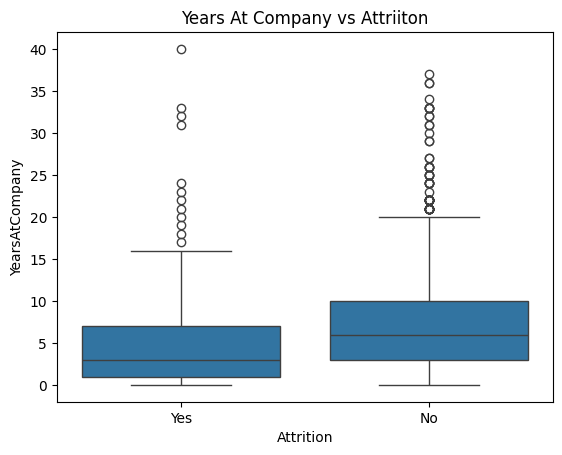

In [40]:
sns.boxplot(data=df,x='Attrition',y='YearsAtCompany')
plt.title('Years At Company vs Attriiton')
plt.show()

In [41]:
joblevel_attrition

JobLevel
1    26.335175
3    14.678899
2     9.737828
5     7.246377
4     4.716981
Name: Attrition, dtype: float64

In [42]:
overtime_attrition

OverTime
Yes    30.528846
No     10.436433
Name: Attrition, dtype: float64

In [44]:
pd.crosstab([df['Department'],df['JobRole']],[df['OverTime'],df['Attrition']],normalize='index')*100

OverTime                                                 No             \
Attrition                                                No        Yes   
Department             JobRole                                           
Human Resources        Human Resources            61.538462  13.461538   
                       Manager                    63.636364   0.000000   
Research & Development Healthcare Representative  66.412214   5.343511   
                       Laboratory Technician      64.092664  11.969112   
                       Manager                    75.925926   0.000000   
                       Manufacturing Director     68.965517   4.137931   
                       Research Director          70.000000   1.250000   
                       Research Scientist         61.986301   4.794521   
Sales                  Manager                    70.270270   2.702703   
                       Sales Executive            63.190184   7.975460   
                       Sales Representative       50.602410  20.481928   

OverTime                                                Yes             
Attrition                                                No        Yes  
Department             JobRole                                          
Human Resources        Human Resources            15.384615   9.615385  
                       Manager                    36.363636   0.000000  
Research & Development Healthcare Representative  26.717557   1.526718  
                       Laboratory Technician      11.969112  11.969112  
                       Manager                    18.518519   5.555556  
                       Manufacturing Director     24.137931   2.758621  
                       Research Director          27.500000   1.250000  
                       Research Scientist         21.917808  11.301370  
Sales                  Manager                    24.324324   2.702703  
                       Sales Executive            19.325153   9.509202  
                       Sales Representative        9.638554  19.277108

In [46]:
pd.crosstab([df['JobRole'],df['OverTime']],df['Attrition'],normalize='index')*100

Attrition                                  No        Yes
JobRole                   OverTime                      
Healthcare Representative No        92.553191   7.446809
                          Yes       94.594595   5.405405
Human Resources           No        82.051282  17.948718
                          Yes       61.538462  38.461538
Laboratory Technician     No        84.263959  15.736041
                          Yes       50.000000  50.000000
Manager                   No        98.666667   1.333333
                          Yes       85.185185  14.814815
Manufacturing Director    No        94.339623   5.660377
                          Yes       89.743590  10.256410
Research Director         No        98.245614   1.754386
                          Yes       95.652174   4.347826
Research Scientist        No        92.820513   7.179487
                          Yes       65.979381  34.020619
Sales Executive           No        88.793103  11.206897
                          Yes       67.021277  32.978723
Sales Representative      No        71.186441  28.813559
                          Yes       33.333333  66.666667

In [51]:
pd.crosstab([df['AgeGroup'],df['OverTime']],df['Attrition'],normalize='index')*100

Attrition                 No        Yes
AgeGroup OverTime                      
18-25    No        78.205128  21.794872
         Yes       37.837838  62.162162
26-35    No        87.919463  12.080537
         Yes       61.006289  38.993711
35-45    No        93.993994   6.006006
         Yes       82.962963  17.037037
46-55    No        91.875000   8.125000
         Yes       80.303030  19.696970
56-65    No        86.666667  13.333333
         Yes       76.470588  23.529412

## Final Conclusion

This Exploratory Data Analysis (EDA) examined employee attrition to identify the employee groups and workplace factors associated with a higher attrition rate.

The overall employee attrition rate was **16.12%**, which was used as the baseline for comparing different employee groups.

The analysis identified several factors with attrition rates above the overall company average. The strongest patterns were observed in **OverTime status, Job Level, Job Role, and Years at Company**.

Employees working **OverTime** showed a relatively higher attrition rate of approximately **30.53%**, compared with approximately **10.44%** among employees who did not work overtime. Further analysis also indicated that **younger employees and employees with shorter tenure at the company** were associated with increased employee attrition.

The combined analysis suggests that attrition is not associated with a single factor. Instead, factors related to **work conditions, career stage, compensation, employee satisfaction, and job characteristics** may interact and contribute to higher observed attrition in specific employee groups.

### Key Takeaways

- Overall attrition rate: **16.12%**
- Highest-risk employee group: **Employees working OverTime**
- Strongest work-related factor: **OverTime**
- Strongest compensation/career-related factor: **Monthly Income / Job Level / Years at Company**
- Strongest employee experience factor: **Job Satisfaction / Work-Life Balance**
- High-risk employee profile: **Younger employees, employees with shorter tenure, lower-income employees, and employees working OverTime showed comparatively higher attrition patterns.**

### Business Recommendations

Based on the patterns identified during the analysis, the organization could consider:

1. Reviewing workload and overtime requirements in high-attrition employee groups.
2. Developing targeted retention strategies for job roles or departments with above-average attrition.
3. Improving onboarding, mentoring, and career support for employees in the early stages of their careers.
4. Reviewing compensation and career growth opportunities for high-risk employee segments.
5. Conducting employee feedback surveys to investigate the underlying reasons behind dissatisfaction and turnover.